# Connectome architecture benchmark

This notebook compares Fly, rewired, and classical feature architectures under the same training and evaluation protocol. The primary architecture comparison is Fly vs rewired; aggregate results across all opponents are reported separately.


In [1]:
!pip install -q python-chess==1.999 pandas pyarrow scipy matplotlib pillow cairosvg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 78.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 8.2 MB/s eta 0:00:00


In [2]:
from io import BytesIO
from pathlib import Path
import gc
import hashlib
import itertools
import json
import math
import os
import random
import shutil
import subprocess
import time

import cairosvg
import chess
import chess.svg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import Image as NotebookImage, display
from scipy import sparse, stats
from scipy.sparse import csgraph

try:
    import torch
except ImportError:
    torch = None

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ
CUDA_AVAILABLE = bool(torch is not None and torch.cuda.is_available())
DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
RESULTS_DIR = Path("/content/connectome_multiseed_results") if IN_COLAB else Path.cwd() / "connectome_multiseed_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Compute device: {DEVICE}")
print(f"Results folder: {RESULTS_DIR}")


# Notebook display defaults
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "medium",
})


Compute device: cuda
Results folder: /content/connectome_multiseed_results


## Experimental settings

Three run profiles are provided. `standard` is the default; `robust` increases both independent training seeds and repeated held-out match trials.


In [3]:
RUN_MODE = "quick"  # "quick", "standard", or "robust", depending on how long do you want to wait
CUSTOM_SEEDS = None  # e.g. [11, 23, 37, ...] to override the default seed

if RUN_MODE == "quick":
    EXPERIMENT_SEEDS = [11, 23, 37, 53, random.randint(10, 999)]
    SELF_PLAY_GAMES = 30
    EVALUATION_SUITES = 1
    POSITIONS_PER_SUITE = 8
    EVALUATION_REPEATS = 1
    HELD_OUT_POSITIONS = 80
    BOOTSTRAP_REPS = 5_000
    SIGN_FLIP_REPS = 50_000
elif RUN_MODE == "standard":
    EXPERIMENT_SEEDS = [11, 23, 37, 53, 71, 89, 107, 131,random.randint(10, 999), random.randint(10, 999)]
    SELF_PLAY_GAMES = 150
    EVALUATION_SUITES = 2
    POSITIONS_PER_SUITE = 12
    EVALUATION_REPEATS = 2
    HELD_OUT_POSITIONS = 200
    BOOTSTRAP_REPS = 10_000
    SIGN_FLIP_REPS = 100_000
elif RUN_MODE == "robust":
    # This is the slowest, but most exhaustive one
    EXPERIMENT_SEEDS = [
        11, 23, 37, 53, 71, 89, 107, 131,
        149, 167, 191, 211, 233, 257, 281, 307, random.randint(10, 999),
        random.randint(10, 999), random.randint(10, 999),random.randint(10, 999),
        random.randint(10, 999)
    ]
    SELF_PLAY_GAMES = 400
    EVALUATION_SUITES = 3
    POSITIONS_PER_SUITE = 16
    EVALUATION_REPEATS = 2
    HELD_OUT_POSITIONS = 400
    BOOTSTRAP_REPS = 30_000
    SIGN_FLIP_REPS = 200_000
else:
    raise ValueError("RUN_MODE must be 'quick', 'standard', or 'robust'.")

if CUSTOM_SEEDS is not None:
    EXPERIMENT_SEEDS = list(CUSTOM_SEEDS)

EVALUATION_POSITIONS = EVALUATION_SUITES * POSITIONS_PER_SUITE
MAX_PLIES = 160 if RUN_MODE == "quick" else 240
TRAINING_OPENING_PLIES = 4
EVALUATION_EXTRA_PLIES = 6
HELD_OUT_EXTRA_PLIES = 14
GIF_GAMES = 4

READOUT_NEURONS = 512
PROPAGATION_STEPS = 5
LEARNING_RATE = 0.002
DISCOUNT = 0.9953
EPSILON_START = 0.40
EPSILON_END = 0.02
MATERIAL_SHAPING = 0.08
DRAW_CONTEMPT = 0.0
RANDOM_SEED = 67
EVALUATION_SUITE_SEED = 20260828
HELD_OUT_SUITE_SEED = 20260829
ANALYSIS_SEED = 20260830
START_FEN = chess.STARTING_FEN

BOARD_FEATURES = 64 * 12 + 1 + 4 + 8 + 1
RESERVOIR_NEURONS = 8192
TRAINABLE_PARAMETERS_PER_AGENT = READOUT_NEURONS + 1
TRAINED_AGENTS = ("fly", "classical", "rewired")
PAIRINGS = (
    ("fly", "classical"),
    ("fly", "rewired"),
    ("classical", "rewired"),
    ("fly", "material"),
    ("classical", "material"),
    ("rewired", "material"),
    ("fly", "random"),
    ("classical", "random"),
)

GAMES_PER_PAIRING_PER_SEED = EVALUATION_POSITIONS * 2 * EVALUATION_REPEATS
settings = {
    "run mode": RUN_MODE,
    "independent training seeds": len(EXPERIMENT_SEEDS),
    "self-play games per agent and seed": SELF_PLAY_GAMES,
    "evaluation suites": EVALUATION_SUITES,
    "positions per suite": POSITIONS_PER_SUITE,
    "evaluation repeats per color": EVALUATION_REPEATS,
    "evaluation positions total": EVALUATION_POSITIONS,
    "games per pairing and seed": GAMES_PER_PAIRING_PER_SEED,
    "learned architecture pairings": 3,
    "held-out diagnostic positions": HELD_OUT_POSITIONS,
    "maximum plies": MAX_PLIES,
    "bootstrap resamples": BOOTSTRAP_REPS,
    "trainable parameters per learned agent": TRAINABLE_PARAMETERS_PER_AGENT,
}
display(pd.DataFrame.from_dict(settings, orient="index", columns=["value"]))

assert BOARD_FEATURES == 782
assert len(EXPERIMENT_SEEDS) >= 2
assert len(set(EXPERIMENT_SEEDS)) == len(EXPERIMENT_SEEDS)
assert GIF_GAMES >= 1


,value
run mode,quick
independent training seeds,5
self-play games per agent and seed,30
evaluation suites,1
positions per suite,8
evaluation repeats per color,1
evaluation positions total,8
games per pairing and seed,16
learned architecture pairings,3
held-out diagnostic positions,80


## Connectome data


In [4]:
DATA_REPOSITORY = "https://github.com/philshiu/Drosophila_brain_model.git"
DATA_DIR = Path("/content/Drosophila_brain_model") if IN_COLAB else Path.cwd() / "Drosophila_brain_model"
CONNECTIVITY_FILE = DATA_DIR / "Connectivity_783.parquet"
COMPLETENESS_FILE = DATA_DIR / "Completeness_783.csv"

if not CONNECTIVITY_FILE.exists():
    if DATA_DIR.exists():
        raise FileNotFoundError(
            f"{DATA_DIR} exists, but Connectivity_783.parquet is missing. "
            "Point DATA_DIR at a complete clone or rename the incomplete folder."
        )
    subprocess.run(
        ["git", "clone", "--depth", "1", DATA_REPOSITORY, str(DATA_DIR)],
        check=True,
    )

if not CONNECTIVITY_FILE.exists():
    raise FileNotFoundError(f"Could not find {CONNECTIVITY_FILE}")

print(f"Connectivity data: {CONNECTIVITY_FILE}")
print(f"Completeness metadata present: {COMPLETENESS_FILE.exists()}")


Connectivity data: /content/Drosophila_brain_model/Connectivity_783.parquet
Completeness metadata present: True


## Board representation


In [5]:
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.2,
    chess.BISHOP: 3.3,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
}


def encode_board(board):
    features = np.zeros(BOARD_FEATURES, dtype=np.float32)

    for square, piece in board.piece_map().items():
        color_offset = 0 if piece.color == chess.WHITE else 6
        piece_index = color_offset + piece.piece_type - 1
        features[square * 12 + piece_index] = 1.0

    offset = 64 * 12
    features[offset] = 1.0 if board.turn == chess.WHITE else -1.0
    offset += 1

    features[offset : offset + 4] = [
        board.has_kingside_castling_rights(chess.WHITE),
        board.has_queenside_castling_rights(chess.WHITE),
        board.has_kingside_castling_rights(chess.BLACK),
        board.has_queenside_castling_rights(chess.BLACK),
    ]
    offset += 4

    if board.ep_square is not None:
        features[offset + chess.square_file(board.ep_square)] = 1.0
    offset += 8

    features[offset] = min(board.halfmove_clock, 100) / 100.0
    return features


def material_score(board):
    score = 0.0
    for piece_type, value in PIECE_VALUES.items():
        score += value * len(board.pieces(piece_type, chess.WHITE))
        score -= value * len(board.pieces(piece_type, chess.BLACK))
    return score


def terminal_reward(board):
    outcome = board.outcome(claim_draw=True)
    if outcome is None:
        return None
    if outcome.winner is None:
        return 0.0
    return 1.0 if outcome.winner == chess.WHITE else -1.0


test_board = chess.Board()
assert encode_board(test_board).shape == (BOARD_FEATURES,)
assert abs(material_score(test_board)) < 1e-9
print("Board encoder checks passed.")


Board encoder checks passed.


## Reservoir construction


In [6]:
def first_present(columns, candidates):
    for name in candidates:
        if name in columns:
            return name
    raise KeyError(f"None of {candidates} were found. Available columns: {list(columns)}")


def build_connectome_reservoir(
    connectivity_file,
    completeness_file,
    reservoir_neurons=None,
):
    if reservoir_neurons is None:
        reservoir_neurons = RESERVOIR_NEURONS
    reservoir_neurons = int(reservoir_neurons)
    minimum_neurons = BOARD_FEATURES + READOUT_NEURONS
    if reservoir_neurons < minimum_neurons:
        print(
            f"Reservoir size increased from {reservoir_neurons:,} to "
            f"{minimum_neurons:,} so the input and readout sets both fit."
        )
        reservoir_neurons = minimum_neurons

    neurons = pd.read_csv(completeness_file, index_col=0)
    edges = pd.read_parquet(connectivity_file)

    pre_col = first_present(
        edges.columns,
        ["Presynaptic_Index", "presynaptic_index", "pre", "source"],
    )
    post_col = first_present(
        edges.columns,
        ["Postsynaptic_Index", "postsynaptic_index", "post", "target"],
    )
    weight_col = first_present(
        edges.columns,
        ["Excitatory x Connectivity", "weight", "connectivity"],
    )

    pre = edges[pre_col].to_numpy(dtype=np.int64, copy=False)
    post = edges[post_col].to_numpy(dtype=np.int64, copy=False)
    weights = edges[weight_col].to_numpy(dtype=np.float32, copy=False)

    neuron_count = len(neurons)
    valid = (
        (pre >= 0)
        & (post >= 0)
        & (pre < neuron_count)
        & (post < neuron_count)
        & np.isfinite(weights)
        & (weights != 0)
    )
    pre, post, weights = pre[valid], post[valid], weights[valid]

    degree = np.bincount(pre, minlength=neuron_count)
    degree += np.bincount(post, minlength=neuron_count)
    start = int(np.argmax(degree))

    structure = sparse.csr_matrix(
        (np.ones(len(pre), dtype=np.uint8), (post, pre)),
        shape=(neuron_count, neuron_count),
    )
    traversal = csgraph.breadth_first_order(
        structure,
        i_start=start,
        directed=False,
        return_predecessors=False,
    )

    if len(traversal) < reservoir_neurons:
        raise ValueError(
            f"The connected component contains only {len(traversal):,} neurons; "
            f"{reservoir_neurons:,} are required."
        )

    selected = traversal[:reservoir_neurons].astype(np.int64)
    local_index = np.full(neuron_count, -1, dtype=np.int64)
    local_index[selected] = np.arange(len(selected))
    keep = (local_index[pre] >= 0) & (local_index[post] >= 0)

    reservoir = sparse.csr_matrix(
        (
            weights[keep],
            (local_index[post[keep]], local_index[pre[keep]]),
        ),
        shape=(len(selected), len(selected)),
        dtype=np.float32,
    )
    reservoir.sum_duplicates()

    row_scale = np.asarray(abs(reservoir).sum(axis=1)).ravel()
    row_scale[row_scale < 1.0] = 1.0
    reservoir = sparse.diags(1.0 / row_scale) @ reservoir
    reservoir = reservoir.astype(np.float32).tocsr()

    readout_pool = np.arange(BOARD_FEATURES, len(selected))
    if len(readout_pool) < READOUT_NEURONS:
        raise ValueError(
            f"The selected reservoir has {len(selected):,} neurons, but at least "
            f"{minimum_neurons:,} are needed for {BOARD_FEATURES:,} input and "
            f"{READOUT_NEURONS:,} readout neurons."
        )
    readout_rng = np.random.default_rng(RANDOM_SEED)
    readout_indices = np.sort(
        readout_rng.choice(
            readout_pool,
            size=READOUT_NEURONS,
            replace=False,
        )
    ).astype(np.int64)

    return reservoir, selected, readout_indices


build_started = time.perf_counter()
fly_matrix, selected_neurons, fly_readout_indices = build_connectome_reservoir(
    CONNECTIVITY_FILE,
    COMPLETENESS_FILE,
)
print(
    f"Fly reservoir: {fly_matrix.shape[0]:,} neurons, "
    f"{fly_matrix.nnz:,} internal edges, "
    f"built in {time.perf_counter() - build_started:.1f}s"
)


Fly reservoir: 8,192 neurons, 168,930 internal edges, built in 7.5s


## Model variants


In [7]:
class FlyConnectomeFeatures:
    name = "fly"

    def __init__(self, matrix, readout_indices):
        self.matrix_cpu = matrix
        self.readout_indices = np.asarray(readout_indices, dtype=np.int64)
        self.use_cuda = CUDA_AVAILABLE

        if self.use_cuda:
            coo = matrix.tocoo()
            indices = torch.as_tensor(
                np.vstack([coo.row, coo.col]),
                dtype=torch.long,
                device=DEVICE,
            )
            values = torch.as_tensor(coo.data, dtype=torch.float32, device=DEVICE)
            self.matrix_gpu = torch.sparse_coo_tensor(
                indices,
                values,
                size=coo.shape,
                device=DEVICE,
            ).coalesce()
            self.readout_gpu = torch.as_tensor(
                self.readout_indices,
                dtype=torch.long,
                device=DEVICE,
            )

    def transform(self, encoded):
        encoded = np.asarray(encoded, dtype=np.float32)
        if encoded.ndim == 1:
            encoded = encoded[:, None]
        batch_size = encoded.shape[1]

        if self.use_cuda:
            with torch.no_grad():
                drive = torch.zeros(
                    (self.matrix_gpu.shape[0], batch_size),
                    dtype=torch.float32,
                    device=DEVICE,
                )
                drive[:BOARD_FEATURES] = torch.as_tensor(encoded, device=DEVICE)
                state = torch.zeros_like(drive)

                for _ in range(PROPAGATION_STEPS):
                    recurrent = torch.sparse.mm(self.matrix_gpu, state)
                    proposal = torch.tanh(1.25 * recurrent + 1.5 * drive)
                    state = 0.35 * state + 0.65 * proposal

                features = state.index_select(0, self.readout_gpu)
                norms = torch.linalg.vector_norm(features, dim=0, keepdim=True).clamp_min(1e-6)
                features = features / norms
                bias = torch.ones((1, batch_size), dtype=torch.float32, device=DEVICE)
                return torch.cat([features, bias], dim=0).cpu().numpy()

        drive = np.zeros((self.matrix_cpu.shape[0], batch_size), dtype=np.float32)
        drive[:BOARD_FEATURES] = encoded
        state = np.zeros_like(drive)
        for _ in range(PROPAGATION_STEPS):
            recurrent = self.matrix_cpu @ state
            proposal = np.tanh(1.25 * recurrent + 1.5 * drive)
            state = 0.35 * state + 0.65 * proposal

        features = state[self.readout_indices]
        norms = np.maximum(np.linalg.norm(features, axis=0, keepdims=True), 1e-6)
        features = features / norms
        return np.vstack([features, np.ones((1, batch_size), dtype=np.float32)])

    def boards(self, boards):
        encoded = np.stack([encode_board(board) for board in boards], axis=1)
        return self.transform(encoded)


class ClassicalRandomFeatures:
    name = "classical"

    def __init__(self, seed=RANDOM_SEED):
        rng = np.random.default_rng(seed)
        scale = 1.0 / math.sqrt(BOARD_FEATURES)
        self.projection_cpu = rng.normal(
            0.0,
            scale,
            size=(READOUT_NEURONS, BOARD_FEATURES),
        ).astype(np.float32)
        self.use_cuda = CUDA_AVAILABLE
        if self.use_cuda:
            self.projection_gpu = torch.as_tensor(
                self.projection_cpu,
                dtype=torch.float32,
                device=DEVICE,
            )

    def transform(self, encoded):
        encoded = np.asarray(encoded, dtype=np.float32)
        if encoded.ndim == 1:
            encoded = encoded[:, None]

        if self.use_cuda:
            with torch.no_grad():
                encoded_gpu = torch.as_tensor(encoded, device=DEVICE)
                features = torch.tanh(1.5 * (self.projection_gpu @ encoded_gpu))
                norms = torch.linalg.vector_norm(features, dim=0, keepdim=True).clamp_min(1e-6)
                features = features / norms
                bias = torch.ones((1, features.shape[1]), dtype=torch.float32, device=DEVICE)
                return torch.cat([features, bias], dim=0).cpu().numpy()

        features = np.tanh(1.5 * (self.projection_cpu @ encoded))
        norms = np.maximum(np.linalg.norm(features, axis=0, keepdims=True), 1e-6)
        features = features / norms
        return np.vstack([features, np.ones((1, features.shape[1]), dtype=np.float32)])

    def boards(self, boards):
        encoded = np.stack([encode_board(board) for board in boards], axis=1)
        return self.transform(encoded)


def normalize_reservoir(matrix):
    matrix = matrix.astype(np.float32).tocsr()
    matrix.sum_duplicates()
    row_scale = np.asarray(abs(matrix).sum(axis=1)).ravel()
    row_scale[row_scale < 1.0] = 1.0
    return (sparse.diags(1.0 / row_scale) @ matrix).astype(np.float32).tocsr()


def rewire_reservoir(matrix, seed):
    coo = matrix.tocoo()
    rng = np.random.default_rng(seed)
    rows = coo.row.copy()
    rng.shuffle(rows)
    rewired = sparse.csr_matrix(
        (coo.data.copy(), (rows, coo.col.copy())),
        shape=coo.shape,
        dtype=np.float32,
    )
    return normalize_reservoir(rewired)


def readout_indices_for_seed(seed):
    rng = np.random.default_rng(seed)
    pool = np.arange(BOARD_FEATURES, fly_matrix.shape[0])
    if len(pool) < READOUT_NEURONS:
        raise ValueError(
            f"Need {READOUT_NEURONS:,} readout neurons, but only {len(pool):,} are available."
        )
    return np.sort(rng.choice(pool, size=READOUT_NEURONS, replace=False)).astype(np.int64)


def build_seed_models(seed):
    readout_indices = readout_indices_for_seed(seed)
    rewired_matrix = rewire_reservoir(fly_matrix, seed + 100_000)
    models = {
        "fly": {
            "features": FlyConnectomeFeatures(fly_matrix, readout_indices),
            "weights": np.zeros(TRAINABLE_PARAMETERS_PER_AGENT, dtype=np.float32),
            "rng": np.random.default_rng(seed + 1),
        },
        "classical": {
            "features": ClassicalRandomFeatures(seed=seed),
            "weights": np.zeros(TRAINABLE_PARAMETERS_PER_AGENT, dtype=np.float32),
            "rng": np.random.default_rng(seed + 2),
        },
        "rewired": {
            "features": FlyConnectomeFeatures(rewired_matrix, readout_indices),
            "weights": np.zeros(TRAINABLE_PARAMETERS_PER_AGENT, dtype=np.float32),
            "rng": np.random.default_rng(seed + 3),
        },
    }
    metadata = {
        "readout_indices": readout_indices,
        "rewired_edges": rewired_matrix.nnz,
    }
    return models, metadata


print(f"Original reservoir edges: {fly_matrix.nnz:,}")


Original reservoir edges: 168,930


## Training


In [8]:
def predict_values(weights, feature_matrix):
    return np.tanh(weights @ feature_matrix)


def epsilon_for_game(game_index):
    if SELF_PLAY_GAMES <= 1:
        return EPSILON_END
    progress = game_index / (SELF_PLAY_GAMES - 1)
    return EPSILON_START + progress * (EPSILON_END - EPSILON_START)


def choose_trained_move(feature_generator, weights, board, epsilon, rng):
    legal_moves = list(board.legal_moves)
    if not legal_moves:
        return None
    if epsilon > 0.0 and rng.random() < epsilon:
        return legal_moves[int(rng.integers(len(legal_moves)))]

    child_boards = []
    immediate_scores = []
    for move in legal_moves:
        child = board.copy(stack=False)
        child.push(move)
        child_boards.append(child)
        reward = terminal_reward(child) if child.is_game_over(claim_draw=True) else None
        if reward == 0.0 and DRAW_CONTEMPT > 0.0:
            reward = -DRAW_CONTEMPT if board.turn == chess.WHITE else DRAW_CONTEMPT
        immediate_scores.append(np.nan if reward is None else reward)

    child_features = feature_generator.boards(child_boards)
    scores = predict_values(weights, child_features)
    terminal_mask = np.isfinite(immediate_scores)
    scores[terminal_mask] = np.asarray(immediate_scores)[terminal_mask]
    best_score = scores.max() if board.turn == chess.WHITE else scores.min()
    best = np.flatnonzero(np.isclose(scores, best_score, atol=1e-7))
    return legal_moves[int(rng.choice(best))]


def train_one_game(feature_generator, weights, epsilon, rng, start_fen):
    board = chess.Board(start_fen)
    absolute_td_error = 0.0
    updates = 0
    for _ in range(MAX_PLIES):
        if board.is_game_over(claim_draw=True):
            break
        current_features = feature_generator.boards([board])[:, 0]
        current_value = float(np.tanh(weights @ current_features))
        material_before = material_score(board)
        move = choose_trained_move(feature_generator, weights, board, epsilon, rng)
        if move is None:
            break
        board.push(move)
        shaping = MATERIAL_SHAPING * (material_score(board) - material_before) / 40.0
        if board.is_game_over(claim_draw=True):
            target = terminal_reward(board) + shaping
        else:
            next_features = feature_generator.boards([board])[:, 0]
            next_value = float(np.tanh(weights @ next_features))
            target = shaping + DISCOUNT * next_value
        target = float(np.clip(target, -1.0, 1.0))
        td_error = target - current_value
        weights += LEARNING_RATE * td_error * (1.0 - current_value * current_value) * current_features
        absolute_td_error += abs(td_error)
        updates += 1

    outcome = board.outcome(claim_draw=True)
    return {
        "result": outcome.result() if outcome else "1/2-1/2",
        "termination": outcome.termination.name.lower() if outcome else "max_plies",
        "plies": board.ply(),
        "mean_abs_td_error": absolute_td_error / max(updates, 1),
    }


def choose_material_move(board, rng):
    legal_moves = list(board.legal_moves)
    if not legal_moves:
        return None
    scores = []
    for move in legal_moves:
        child = board.copy(stack=False)
        child.push(move)
        reward = terminal_reward(child) if child.is_game_over(claim_draw=True) else None
        scores.append(material_score(child) / 40.0 if reward is None else reward)
    scores = np.asarray(scores)
    best_score = scores.max() if board.turn == chess.WHITE else scores.min()
    best = np.flatnonzero(np.isclose(scores, best_score, atol=1e-7))
    return legal_moves[int(rng.choice(best))]


def choose_agent_move(agent_name, models, board, rng):
    if agent_name == "random":
        legal_moves = list(board.legal_moves)
        return None if not legal_moves else legal_moves[int(rng.integers(len(legal_moves)))]
    if agent_name == "material":
        return choose_material_move(board, rng)
    model = models[agent_name]
    return choose_trained_move(model["features"], model["weights"], board, 0.0, rng)


## Evaluation positions

Evaluation uses several disjoint position suites. Each position is played with both color assignments and, outside quick mode, repeated with a different tie-breaking random seed.


In [9]:
OPENING_PREFIXES = (
    ("e2e4", "e7e5"),
    ("e2e4", "c7c5"),
    ("e2e4", "e7e6"),
    ("e2e4", "c7c6"),
    ("d2d4", "d7d5"),
    ("d2d4", "g8f6"),
    ("c2c4", "e7e5"),
    ("g1f3", "d7d5"),
)


def make_position_suite(count, seed, max_extra_plies, exclude=()):
    rng = np.random.default_rng(seed)
    positions = []
    seen = set(exclude)
    attempts = 0
    while len(positions) < count:
        board = chess.Board(START_FEN)
        prefix = OPENING_PREFIXES[attempts % len(OPENING_PREFIXES)]
        for move_uci in prefix:
            move = chess.Move.from_uci(move_uci)
            if move in board.legal_moves:
                board.push(move)
        extra_plies = int(rng.integers(0, max_extra_plies + 1))
        for _ in range(extra_plies):
            legal_moves = list(board.legal_moves)
            if not legal_moves or board.is_game_over(claim_draw=True):
                break
            board.push(legal_moves[int(rng.integers(len(legal_moves)))])
        fen = board.fen()
        if fen not in seen and not board.is_game_over(claim_draw=True):
            seen.add(fen)
            positions.append(fen)
        attempts += 1
        if attempts > count * 200:
            raise RuntimeError("Could not create enough unique positions.")
    return positions


evaluation_suites = {}
used_evaluation_fens = set()
for suite_index in range(EVALUATION_SUITES):
    suite_id = suite_index + 1
    suite_seed = EVALUATION_SUITE_SEED + suite_index * 10_003
    suite_fens = make_position_suite(
        POSITIONS_PER_SUITE,
        suite_seed,
        EVALUATION_EXTRA_PLIES,
        exclude=used_evaluation_fens,
    )
    evaluation_suites[suite_id] = suite_fens
    used_evaluation_fens.update(suite_fens)

evaluation_fens = [fen for suite in evaluation_suites.values() for fen in suite]
held_out_fens = make_position_suite(
    HELD_OUT_POSITIONS,
    HELD_OUT_SUITE_SEED,
    HELD_OUT_EXTRA_PLIES,
    exclude=used_evaluation_fens,
)

assert len(evaluation_fens) == EVALUATION_POSITIONS
assert len(set(evaluation_fens)) == EVALUATION_POSITIONS
assert set(evaluation_fens).isdisjoint(held_out_fens)
print(f"Evaluation suites: {EVALUATION_SUITES}")
print(f"Evaluation positions: {len(evaluation_fens)}")
print(f"Repeated games per position and pairing: {2 * EVALUATION_REPEATS}")
print(f"Held-out diagnostic positions: {len(held_out_fens)}")


Evaluation suites: 1
Evaluation positions: 8
Repeated games per position and pairing: 2
Held-out diagnostic positions: 80


## Match evaluation


In [10]:
def play_match_game(models, white_name, black_name, start_fen, game_seed):
    board = chess.Board(start_fen)
    rng = np.random.default_rng(game_seed)
    positions = [board.fen()]
    labels = ["Start"]
    moves_san = []
    moves_uci = []
    started = time.perf_counter()

    for _ in range(MAX_PLIES):
        if board.is_game_over(claim_draw=True):
            break
        player_name = white_name if board.turn == chess.WHITE else black_name
        move = choose_agent_move(player_name, models, board, rng)
        if move is None:
            break
        san = board.san(move)
        move_number = board.fullmove_number
        prefix = f"{move_number}." if board.turn == chess.WHITE else f"{move_number}..."
        moves_uci.append(move.uci())
        moves_san.append(san)
        board.push(move)
        positions.append(board.fen())
        labels.append(f"{prefix} {san}")

    outcome = board.outcome(claim_draw=True)
    result = outcome.result() if outcome else "1/2-1/2"
    if result == "1-0":
        winner = white_name
    elif result == "0-1":
        winner = black_name
    else:
        winner = "draw"
    move_text = " ".join(moves_uci)
    return {
        "white": white_name,
        "black": black_name,
        "result": result,
        "winner": winner,
        "termination": outcome.termination.name.lower() if outcome else "max_plies",
        "plies": board.ply(),
        "seconds": time.perf_counter() - started,
        "final_material": material_score(board),
        "game_hash": hashlib.sha256(move_text.encode("utf-8")).hexdigest()[:16],
        "moves_uci": move_text,
        "moves_san": moves_san,
        "positions": positions,
        "labels": labels,
    }


## Experiment

Every trained seed is evaluated on the same disjoint suites. Learned architectures are also evaluated directly against one another.


In [11]:
training_rows = []
game_rows = []
diagnostic_rows = []
gif_candidates = []
experiment_started = time.perf_counter()

for seed_index, seed in enumerate(EXPERIMENT_SEEDS):
    print(f"\nSeed {seed} ({seed_index + 1}/{len(EXPERIMENT_SEEDS)})")
    random.seed(seed)
    np.random.seed(seed)
    if torch is not None:
        torch.manual_seed(seed)
        if CUDA_AVAILABLE:
            torch.cuda.manual_seed_all(seed)

    models, seed_metadata = build_seed_models(seed)
    training_fens = make_position_suite(
        SELF_PLAY_GAMES,
        seed + 200_000,
        TRAINING_OPENING_PLIES,
    )
    seed_started = time.perf_counter()

    for game_index, start_fen in enumerate(training_fens):
        epsilon = epsilon_for_game(game_index)
        for agent_name in TRAINED_AGENTS:
            model = models[agent_name]
            game_started = time.perf_counter()
            result = train_one_game(
                model["features"],
                model["weights"],
                epsilon,
                model["rng"],
                start_fen,
            )
            training_rows.append(
                {
                    "seed": seed,
                    "agent": agent_name,
                    "game": game_index + 1,
                    "epsilon": epsilon,
                    "seconds": time.perf_counter() - game_started,
                    **result,
                }
            )

        report_every = max(1, SELF_PLAY_GAMES // 5)
        if (game_index + 1) % report_every == 0 or game_index == 0:
            print(f"  trained {game_index + 1}/{SELF_PLAY_GAMES} games per agent")

    held_out_boards = [chess.Board(fen) for fen in held_out_fens]
    material_targets = np.tanh(
        np.asarray([material_score(board) for board in held_out_boards], dtype=np.float32) / 10.0
    )
    for agent_name in TRAINED_AGENTS:
        model = models[agent_name]
        values = predict_values(
            model["weights"],
            model["features"].boards(held_out_boards),
        )
        if values.std() > 1e-8 and material_targets.std() > 1e-8:
            correlation = np.corrcoef(values, material_targets)[0, 1]
        else:
            correlation = np.nan
        diagnostic_rows.append(
            {
                "seed": seed,
                "agent": agent_name,
                "positions": len(held_out_boards),
                "value_mean": float(values.mean()),
                "value_std": float(values.std()),
                "material_correlation": float(correlation) if np.isfinite(correlation) else np.nan,
            }
        )

    for pairing_index, (first, second) in enumerate(PAIRINGS):
        pairing_name = f"{first}_vs_{second}"
        for suite_id, suite_fens in evaluation_suites.items():
            for position_index, start_fen in enumerate(suite_fens):
                for eval_repeat in range(EVALUATION_REPEATS):
                    for swap in (0, 1):
                        white_name, black_name = (first, second) if swap == 0 else (second, first)
                        game_seed = (
                            seed * 1_000_000_000
                            + pairing_index * 10_000_000
                            + suite_id * 100_000
                            + position_index * 1_000
                            + eval_repeat * 10
                            + swap
                        )
                        game = play_match_game(
                            models,
                            white_name,
                            black_name,
                            start_fen,
                            game_seed,
                        )
                        game.update(
                            {
                                "seed": seed,
                                "pairing": pairing_name,
                                "suite": suite_id,
                                "position": position_index + 1,
                                "eval_repeat": eval_repeat + 1,
                                "start_fen": start_fen,
                            }
                        )
                        game_rows.append(
                            {
                                key: value
                                for key, value in game.items()
                                if key not in {"positions", "labels", "moves_san"}
                            }
                        )
                        if len(gif_candidates) < 80:
                            gif_candidates.append(game)

    np.savez_compressed(
        RESULTS_DIR / f"seed_{seed}_models.npz",
        fly_weights=models["fly"]["weights"],
        classical_weights=models["classical"]["weights"],
        rewired_weights=models["rewired"]["weights"],
        classical_projection=models["classical"]["features"].projection_cpu,
        readout_indices=seed_metadata["readout_indices"],
        selected_fly_neurons=selected_neurons,
        seed=np.asarray(seed),
    )

    pd.DataFrame(training_rows).to_csv(RESULTS_DIR / "training_history.csv", index=False)
    pd.DataFrame(game_rows).to_csv(RESULTS_DIR / "evaluation_games.csv", index=False)
    pd.DataFrame(diagnostic_rows).to_csv(RESULTS_DIR / "position_diagnostics.csv", index=False)
    print(f"  seed finished in {time.perf_counter() - seed_started:.1f}s")

    del models
    gc.collect()
    if CUDA_AVAILABLE:
        torch.cuda.empty_cache()

print(f"\nExperiment finished in {(time.perf_counter() - experiment_started) / 60:.1f} minutes")



Seed 11 (1/5)


/tmp/ipykernel_3360/1615314842.py:17: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  self.matrix_gpu = torch.sparse_coo_tensor(


  trained 1/30 games per agent
  trained 6/30 games per agent
  trained 12/30 games per agent
  trained 18/30 games per agent
  trained 24/30 games per agent
  trained 30/30 games per agent
  seed finished in 188.4s

Seed 23 (2/5)
  trained 1/30 games per agent
  trained 6/30 games per agent
  trained 12/30 games per agent
  trained 18/30 games per agent
  trained 24/30 games per agent
  trained 30/30 games per agent
  seed finished in 174.5s

Seed 37 (3/5)
  trained 1/30 games per agent
  trained 6/30 games per agent
  trained 12/30 games per agent
  trained 18/30 games per agent
  trained 24/30 games per agent
  trained 30/30 games per agent
  seed finished in 167.5s

Seed 53 (4/5)
  trained 1/30 games per agent
  trained 6/30 games per agent
  trained 12/30 games per agent
  trained 18/30 games per agent
  trained 24/30 games per agent
  trained 30/30 games per agent
  seed finished in 169.4s

Seed 992 (5/5)
  trained 1/30 games per agent
  trained 6/30 games per agent
  trained 12/

## Results


In [12]:
training_history = pd.DataFrame(training_rows)
game_table = pd.DataFrame(game_rows)
position_diagnostics = pd.DataFrame(diagnostic_rows)

agent_rows = []
for game_id, row in enumerate(game_table.itertuples(index=False)):
    if row.result == "1-0":
        white_score, black_score = 1.0, 0.0
    elif row.result == "0-1":
        white_score, black_score = 0.0, 1.0
    else:
        white_score = black_score = 0.5

    for agent, opponent, color, score in (
        (row.white, row.black, "white", white_score),
        (row.black, row.white, "black", black_score),
    ):
        agent_rows.append(
            {
                "game_id": game_id,
                "seed": row.seed,
                "pairing": row.pairing,
                "suite": row.suite,
                "position": row.position,
                "eval_repeat": row.eval_repeat,
                "agent": agent,
                "opponent": opponent,
                "color": color,
                "score": score,
                "outcome": "win" if score == 1.0 else "loss" if score == 0.0 else "draw",
                "termination": row.termination,
                "plies": row.plies,
                "seconds_per_ply": row.seconds / max(row.plies, 1),
                "game_hash": row.game_hash,
            }
        )

agent_table = pd.DataFrame(agent_rows)
seed_results = (
    agent_table.groupby(["seed", "pairing", "agent", "opponent"], as_index=False)
    .agg(
        games=("score", "size"),
        wins=("outcome", lambda x: int((x == "win").sum())),
        draws=("outcome", lambda x: int((x == "draw").sum())),
        losses=("outcome", lambda x: int((x == "loss").sum())),
        score_fraction=("score", "mean"),
        average_plies=("plies", "mean"),
        milliseconds_per_ply=("seconds_per_ply", lambda x: 1000.0 * x.mean()),
        unique_games=("game_id", "nunique"),
    )
)

suite_results = (
    agent_table.groupby(["seed", "suite", "pairing", "agent", "opponent"], as_index=False)
    .agg(
        games=("score", "size"),
        score_fraction=("score", "mean"),
        wins=("outcome", lambda x: int((x == "win").sum())),
        draws=("outcome", lambda x: int((x == "draw").sum())),
        losses=("outcome", lambda x: int((x == "loss").sum())),
    )
)


def mean_t_ci(values, level=0.95, clip=(0.0, 1.0)):
    values = np.asarray(values, dtype=float)
    mean = float(values.mean())
    if len(values) < 2:
        return mean, np.nan, np.nan
    sem = float(stats.sem(values))
    half = float(stats.t.ppf(0.5 + level / 2.0, len(values) - 1) * sem)
    low, high = mean - half, mean + half
    if clip is not None:
        low, high = max(clip[0], low), min(clip[1], high)
    return mean, low, high


aggregate_rows = []
for keys, group in seed_results.groupby(["pairing", "agent", "opponent"]):
    mean, low, high = mean_t_ci(group["score_fraction"].to_numpy())
    aggregate_rows.append(
        {
            "pairing": keys[0],
            "agent": keys[1],
            "opponent": keys[2],
            "seeds": len(group),
            "mean_score": mean,
            "ci95_low": low,
            "ci95_high": high,
            "mean_unique_games": float(group["unique_games"].mean()),
            "mean_milliseconds_per_ply": float(group["milliseconds_per_ply"].mean()),
        }
    )

aggregate_results = pd.DataFrame(aggregate_rows)
color_results = (
    agent_table.groupby(["agent", "opponent", "color"], as_index=False)
    .agg(games=("score", "size"), score_fraction=("score", "mean"))
)
termination_results = (
    game_table.groupby(["pairing", "termination"], as_index=False)
    .size()
    .rename(columns={"size": "games"})
)

# Fly summaries: one row per evaluated Fly game.
fly_games = agent_table[agent_table["agent"] == "fly"].copy()
expected_fly_games = int(((game_table["white"] == "fly") | (game_table["black"] == "fly")).sum())
assert len(fly_games) == expected_fly_games
assert fly_games["game_id"].nunique() == expected_fly_games


def summarize_outcomes(group, label):
    n = len(group)
    wins = int((group["outcome"] == "win").sum())
    draws = int((group["outcome"] == "draw").sum())
    losses = int((group["outcome"] == "loss").sum())
    return {
        "group": label,
        "games": n,
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "win_pct": 100.0 * wins / n,
        "draw_pct": 100.0 * draws / n,
        "loss_pct": 100.0 * losses / n,
        "match_score": float(group["score"].mean()),
    }


fly_outcomes = pd.DataFrame(
    [summarize_outcomes(fly_games, "overall")]
    + [
        summarize_outcomes(group, f"vs {opponent}")
        for opponent, group in fly_games.groupby("opponent", sort=True)
    ]
)
assert np.allclose(
    fly_outcomes[["win_pct", "draw_pct", "loss_pct"]].sum(axis=1),
    100.0,
)

fly_by_seed_opponent = (
    fly_games.groupby(["seed", "opponent"], as_index=False)
    .agg(
        games=("score", "size"),
        wins=("outcome", lambda x: int((x == "win").sum())),
        draws=("outcome", lambda x: int((x == "draw").sum())),
        losses=("outcome", lambda x: int((x == "loss").sum())),
        score_fraction=("score", "mean"),
    )
)

all_game_score = fly_games.groupby("seed")["score"].mean().rename("all_game_score")
opponent_balanced = (
    fly_by_seed_opponent.groupby("seed")["score_fraction"]
    .mean()
    .rename("opponent_balanced_score")
)
learned_control = (
    fly_by_seed_opponent[fly_by_seed_opponent["opponent"].isin(["classical", "rewired"])]
    .groupby("seed")["score_fraction"]
    .mean()
    .rename("learned_control_score")
)
rewired_score = (
    fly_by_seed_opponent[fly_by_seed_opponent["opponent"] == "rewired"]
    .set_index("seed")["score_fraction"]
    .rename("rewired_score")
)

seed_wdl = fly_games.groupby("seed").agg(
    games=("score", "size"),
    wins=("outcome", lambda x: int((x == "win").sum())),
    draws=("outcome", lambda x: int((x == "draw").sum())),
    losses=("outcome", lambda x: int((x == "loss").sum())),
)

overall_fly_by_seed = (
    seed_wdl.join(all_game_score)
    .join(opponent_balanced)
    .join(learned_control)
    .join(rewired_score)
    .reset_index()
)

seed_results.to_csv(RESULTS_DIR / "seed_results.csv", index=False)
suite_results.to_csv(RESULTS_DIR / "suite_results.csv", index=False)
aggregate_results.to_csv(RESULTS_DIR / "aggregate_results.csv", index=False)
color_results.to_csv(RESULTS_DIR / "color_results.csv", index=False)
termination_results.to_csv(RESULTS_DIR / "termination_results.csv", index=False)
fly_outcomes.to_csv(RESULTS_DIR / "fly_outcomes.csv", index=False)
overall_fly_by_seed.to_csv(RESULTS_DIR / "overall_fly_by_seed.csv", index=False)

display(fly_outcomes.round(3))
display(overall_fly_by_seed.round(3))
display(aggregate_results.sort_values(["pairing", "agent"]).round(4))


,group,games,wins,draws,losses,win_pct,draw_pct,loss_pct,match_score
0,overall,320,66,201,53,20.625,62.812,16.562,0.520
1,vs classical,80,12,61,7,15.000,76.250,8.750,0.531
2,vs material,80,0,49,31,0.000,61.250,38.750,0.306
3,vs random,80,38,42,0,47.500,52.500,0.000,0.738
4,vs rewired,80,16,49,15,20.000,61.250,18.750,0.506


,seed,games,wins,draws,losses,all_game_score,opponent_balanced_score,learned_control_score,rewired_score
0,11,64,14,38,12,0.516,0.516,0.516,0.469
1,23,64,13,38,13,0.500,0.500,0.500,0.500
2,37,64,9,47,8,0.508,0.508,0.469,0.406
3,53,64,18,33,13,0.539,0.539,0.594,0.625
4,992,64,12,45,7,0.539,0.539,0.516,0.531


,pairing,agent,opponent,seeds,mean_score,ci95_low,ci95_high,mean_unique_games,mean_milliseconds_per_ply
0,classical_vs_material,classical,material,5,0.2625,0.1210,0.4040,16.0,6.3617
1,classical_vs_material,material,classical,5,0.7375,0.5960,0.8790,16.0,6.3617
2,classical_vs_random,classical,random,5,0.7188,0.6364,0.8011,16.0,6.1062
3,classical_vs_random,random,classical,5,0.2812,0.1989,0.3636,16.0,6.1062
4,classical_vs_rewired,classical,rewired,5,0.4562,0.4215,0.4910,16.0,13.1979
5,classical_vs_rewired,rewired,classical,5,0.5438,0.5090,0.5785,16.0,13.1979
6,fly_vs_classical,classical,fly,5,0.4688,0.4299,0.5076,16.0,12.9245
7,fly_vs_classical,fly,classical,5,0.5312,0.4924,0.5701,16.0,12.9245
8,fly_vs_material,fly,material,5,0.3062,0.2021,0.4104,16.0,6.6251
9,fly_vs_material,material,fly,5,0.6938,0.5896,0.7979,16.0,6.6251


## Statistical analysis

Training seed is the independent replicate. Match repeats, color swaps, positions, and evaluation suites increase measurement precision but are not counted as independent seeds. Fly vs rewired remains the primary topology comparison.


In [13]:
def bootstrap_mean_ci(values, reps=BOOTSTRAP_REPS, seed=ANALYSIS_SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    draws = rng.choice(values, size=(reps, len(values)), replace=True).mean(axis=1)
    return tuple(np.quantile(draws, [0.025, 0.975]))


def sign_flip_p(values, null=0.5, alternative="two-sided", seed=ANALYSIS_SEED):
    """Exact sign-flip test for <=16 seeds; Monte Carlo beyond that."""
    values = np.asarray(values, dtype=float)
    diff = values - null
    observed = float(diff.mean())
    tol = 1e-12

    if len(diff) <= 16:
        signs = np.asarray(list(itertools.product((-1.0, 1.0), repeat=len(diff))))
        null_means = (signs * diff).mean(axis=1)
        method = "exact"
    else:
        rng = np.random.default_rng(seed)
        signs = rng.choice((-1.0, 1.0), size=(SIGN_FLIP_REPS, len(diff)))
        null_means = (signs * diff).mean(axis=1)
        method = f"monte_carlo_{SIGN_FLIP_REPS}"

    if alternative == "greater":
        p = float(np.mean(null_means >= observed - tol))
    else:
        p = float(np.mean(np.abs(null_means) >= abs(observed) - tol))
    return p, method


def wilcoxon_p(values, null=0.5, alternative="two-sided"):
    diff = np.asarray(values, dtype=float) - null
    if np.allclose(diff, 0.0):
        return 1.0
    try:
        return float(stats.wilcoxon(diff, alternative=alternative, zero_method="wilcox").pvalue)
    except ValueError:
        return np.nan


def seed_direction_p(values, null=0.5, alternative="two-sided"):
    values = np.asarray(values, dtype=float)
    non_ties = values[~np.isclose(values, null)]
    if len(non_ties) == 0:
        return 1.0
    successes = int((non_ties > null).sum())
    return float(stats.binomtest(successes, len(non_ties), 0.5, alternative=alternative).pvalue)


def holm_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    adjusted = np.full_like(pvalues, np.nan)
    valid = np.isfinite(pvalues)
    if not valid.any():
        return adjusted
    vals = pvalues[valid]
    order = np.argsort(vals)
    temp = np.empty_like(vals)
    running = 0.0
    m = len(vals)
    for rank, idx in enumerate(order):
        candidate = (m - rank) * vals[idx]
        running = max(running, candidate)
        temp[idx] = min(1.0, running)
    adjusted[valid] = temp
    return adjusted


def test_seed_scores(label, values):
    values = np.asarray(values, dtype=float)
    mean, ci_low, ci_high = mean_t_ci(values)
    boot_low, boot_high = bootstrap_mean_ci(values)
    sd = float(values.std(ddof=1)) if len(values) > 1 else np.nan
    cohens_dz = (mean - 0.5) / sd if np.isfinite(sd) and sd > 0 else np.nan

    if np.allclose(values, values[0]):
        t_greater = 1.0 if values[0] <= 0.5 else 0.0
        t_two_sided = 1.0 if np.isclose(values[0], 0.5) else 0.0
    else:
        t_greater = float(stats.ttest_1samp(values, 0.5, alternative="greater").pvalue)
        t_two_sided = float(stats.ttest_1samp(values, 0.5).pvalue)

    sign_greater, sign_method = sign_flip_p(values, alternative="greater")
    sign_two_sided, _ = sign_flip_p(values)
    if len(values) > 2:
        loo_means = np.asarray([np.delete(values, i).mean() for i in range(len(values))])
        loo_low, loo_high = float(loo_means.min()), float(loo_means.max())
    else:
        loo_low = loo_high = np.nan

    return {
        "scope": label,
        "seeds": len(values),
        "mean_score": mean,
        "effect_vs_0.5": mean - 0.5,
        "cohens_dz": cohens_dz,
        "t_ci95_low": ci_low,
        "t_ci95_high": ci_high,
        "seed_boot_ci95_low": float(boot_low),
        "seed_boot_ci95_high": float(boot_high),
        "leave_one_seed_out_low": loo_low,
        "leave_one_seed_out_high": loo_high,
        "seeds_above_0.5": int((values > 0.5).sum()),
        "seeds_equal_0.5": int(np.isclose(values, 0.5).sum()),
        "p_t_greater": t_greater,
        "p_t_two_sided": t_two_sided,
        "p_wilcoxon_greater": wilcoxon_p(values, alternative="greater"),
        "p_wilcoxon_two_sided": wilcoxon_p(values),
        "p_seed_direction_greater": seed_direction_p(values, alternative="greater"),
        "p_seed_direction_two_sided": seed_direction_p(values),
        "p_signflip_greater": sign_greater,
        "p_signflip_two_sided": sign_two_sided,
        "signflip_method": sign_method,
    }


scope_scores = {
    "all opponents, balanced": overall_fly_by_seed.set_index("seed")["opponent_balanced_score"],
    "learned controls, balanced": overall_fly_by_seed.set_index("seed")["learned_control_score"],
}
for opponent in sorted(fly_by_seed_opponent["opponent"].unique()):
    scope_scores[f"vs {opponent}"] = (
        fly_by_seed_opponent[fly_by_seed_opponent["opponent"] == opponent]
        .set_index("seed")["score_fraction"]
    )

fly_robust_tests = pd.DataFrame(
    [test_seed_scores(label, values.to_numpy()) for label, values in scope_scores.items()]
)
opponent_mask = fly_robust_tests["scope"].str.startswith("vs ")
fly_robust_tests["holm_signflip_two_sided"] = np.nan
fly_robust_tests.loc[opponent_mask, "holm_signflip_two_sided"] = holm_adjust(
    fly_robust_tests.loc[opponent_mask, "p_signflip_two_sided"].to_numpy()
)

# Direct learned-architecture comparisons. Each row tests the first model's score against 0.5.
learned_matchups = [("fly", "rewired"), ("fly", "classical"), ("classical", "rewired")]
pairwise_rows = []
for first, second in learned_matchups:
    values = (
        seed_results[(seed_results["agent"] == first) & (seed_results["opponent"] == second)]
        .sort_values("seed")["score_fraction"]
        .to_numpy()
    )
    row = test_seed_scores(f"{first} vs {second}", values)
    row["first_agent"] = first
    row["second_agent"] = second
    pairwise_rows.append(row)

architecture_pairwise_tests = pd.DataFrame(pairwise_rows)
architecture_pairwise_tests["holm_signflip_two_sided"] = holm_adjust(
    architecture_pairwise_tests["p_signflip_two_sided"].to_numpy()
)
architecture_pairwise_tests["holm_wilcoxon_two_sided"] = holm_adjust(
    architecture_pairwise_tests["p_wilcoxon_two_sided"].to_numpy()
)

# Primary topology comparison: color swaps and repeats are averaged within each seed-position block.
primary_blocks = (
    fly_games[fly_games["opponent"] == "rewired"]
    .groupby(["seed", "suite", "position"], as_index=False)
    .agg(
        block_score=("score", "mean"),
        games=("score", "size"),
        colors=("color", "nunique"),
        repeats=("eval_repeat", "nunique"),
    )
)
assert (primary_blocks["games"] == 2 * EVALUATION_REPEATS).all()
assert (primary_blocks["colors"] == 2).all()
assert (primary_blocks["repeats"] == EVALUATION_REPEATS).all()


def two_way_bootstrap_ci(blocks, reps=BOOTSTRAP_REPS, seed=ANALYSIS_SEED + 1):
    matrix = blocks.pivot(index="seed", columns=["suite", "position"], values="block_score").to_numpy()
    if np.isnan(matrix).any():
        raise ValueError("The paired seed-by-position table has missing cells.")
    rng = np.random.default_rng(seed)
    n_seeds, n_positions = matrix.shape
    sims = np.empty(reps, dtype=float)
    for i in range(reps):
        seed_idx = rng.integers(0, n_seeds, size=n_seeds)
        position_idx = rng.integers(0, n_positions, size=n_positions)
        sims[i] = matrix[np.ix_(seed_idx, position_idx)].mean()
    return tuple(np.quantile(sims, [0.025, 0.975]))


primary_boot_low, primary_boot_high = two_way_bootstrap_ci(primary_blocks)
primary_summary = pd.DataFrame(
    [{
        "comparison": "fly vs rewired",
        "score": float(primary_blocks["block_score"].mean()),
        "two_way_boot_ci95_low": float(primary_boot_low),
        "two_way_boot_ci95_high": float(primary_boot_high),
        "seeds": int(primary_blocks["seed"].nunique()),
        "suites": int(primary_blocks["suite"].nunique()),
        "positions": int(primary_blocks[["suite", "position"]].drop_duplicates().shape[0]),
        "repeats_per_color": EVALUATION_REPEATS,
        "games": int(primary_blocks["games"].sum()),
    }]
)

# Replication across independently generated evaluation suites.
rewired_suite_seed = (
    fly_games[fly_games["opponent"] == "rewired"]
    .groupby(["seed", "suite"], as_index=False)["score"]
    .mean()
)
suite_rows = []
for suite_id, group in rewired_suite_seed.groupby("suite"):
    mean, low, high = mean_t_ci(group["score"].to_numpy())
    suite_rows.append(
        {
            "suite": int(suite_id),
            "seeds": int(group["seed"].nunique()),
            "mean_score": mean,
            "ci95_low": low,
            "ci95_high": high,
            "effect_vs_0.5": mean - 0.5,
        }
    )
fly_vs_rewired_by_suite = pd.DataFrame(suite_rows)

# Color sensitivity: positive values mean Fly scored better as White.
fly_color_seed = (
    fly_games.groupby(["seed", "opponent", "color"], as_index=False)["score"]
    .mean()
    .pivot(index=["seed", "opponent"], columns="color", values="score")
    .reset_index()
)
color_rows = []
for opponent, group in fly_color_seed.groupby("opponent"):
    diff = (group["white"] - group["black"]).to_numpy()
    mean, low, high = mean_t_ci(diff, clip=None)
    p = float(stats.ttest_1samp(diff, 0.0).pvalue) if len(diff) > 1 and not np.allclose(diff, diff[0]) else np.nan
    color_rows.append(
        {
            "opponent": opponent,
            "seeds": len(diff),
            "white_minus_black": mean,
            "ci95_low": low,
            "ci95_high": high,
            "p_t_two_sided": p,
        }
    )
fly_color_sensitivity = pd.DataFrame(color_rows)

# Sensitivity to games truncated at MAX_PLIES.
non_cap = fly_games[fly_games["termination"] != "max_plies"]
termination_sensitivity = pd.DataFrame(
    [
        {
            "sample": "all fly games",
            "games": len(fly_games),
            "match_score": float(fly_games["score"].mean()),
            "max_plies_pct": 100.0 * float((fly_games["termination"] == "max_plies").mean()),
        },
        {
            "sample": "excluding max_plies",
            "games": len(non_cap),
            "match_score": float(non_cap["score"].mean()) if len(non_cap) else np.nan,
            "max_plies_pct": 0.0,
        },
    ]
)

fly_robust_tests.to_csv(RESULTS_DIR / "fly_robust_tests.csv", index=False)
architecture_pairwise_tests.to_csv(RESULTS_DIR / "architecture_pairwise_tests.csv", index=False)
primary_blocks.to_csv(RESULTS_DIR / "fly_vs_rewired_paired_blocks.csv", index=False)
primary_summary.to_csv(RESULTS_DIR / "fly_vs_rewired_bootstrap.csv", index=False)
fly_vs_rewired_by_suite.to_csv(RESULTS_DIR / "fly_vs_rewired_by_suite.csv", index=False)
fly_color_sensitivity.to_csv(RESULTS_DIR / "fly_color_sensitivity.csv", index=False)
termination_sensitivity.to_csv(RESULTS_DIR / "fly_termination_sensitivity.csv", index=False)

display(fly_robust_tests.round(4))
display(architecture_pairwise_tests.round(4))
display(primary_summary.round(4))
display(fly_vs_rewired_by_suite.round(4))
display(fly_color_sensitivity.round(4))
display(termination_sensitivity.round(3))

if RUN_MODE == "quick":
    print("Quick mode is for code checks only. Use standard or robust mode for inference.")
elif RUN_MODE == "standard":
    print("Standard mode uses eight independent seeds. Use robust mode for the final reported comparison if runtime permits.")


,scope,seeds,mean_score,effect_vs_0.5,cohens_dz,t_ci95_low,t_ci95_high,seed_boot_ci95_low,seed_boot_ci95_high,leave_one_seed_out_low,leave_one_seed_out_high,seeds_above_0.5,seeds_equal_0.5,p_t_greater,p_t_two_sided,p_wilcoxon_greater,p_wilcoxon_two_sided,p_seed_direction_greater,p_seed_direction_two_sided,p_signflip_greater,p_signflip_two_sided,signflip_method,holm_signflip_two_sided
0,"all opponents, balanced",5,0.5203,0.0203,1.1294,0.4980,0.5426,0.5062,0.5344,0.5156,0.5254,4,1,0.0325,0.0650,0.0625,0.1250,0.0625,0.1250,0.0625,0.1250,exact,NaN
1,"learned controls, balanced",5,0.5188,0.0188,0.4068,0.4615,0.5760,0.4875,0.5594,0.5000,0.5312,3,1,0.2072,0.4144,0.3125,0.6250,0.3125,0.6250,0.3125,0.6250,exact,NaN
2,vs classical,5,0.5312,0.0312,1.0000,0.4924,0.5701,0.5062,0.5562,0.5234,0.5391,3,2,0.0445,0.0890,0.1250,0.2500,0.1250,0.2500,0.1250,0.2500,exact,0.50
3,vs material,5,0.3062,-0.1937,-2.3106,0.2021,0.4104,0.2438,0.3688,0.2812,0.3281,0,0,0.9967,0.0067,1.0000,0.0625,1.0000,0.0625,1.0000,0.0625,exact,0.25
4,vs random,5,0.7375,0.2375,5.0113,0.6787,0.7963,0.7000,0.7750,0.7266,0.7500,5,0,0.0002,0.0004,0.0312,0.0625,0.0312,0.0625,0.0312,0.0625,exact,0.25
5,vs rewired,5,0.5062,0.0062,0.0773,0.4058,0.6067,0.4438,0.5750,0.4766,0.5312,2,1,0.4356,0.8712,0.5000,1.0000,0.6875,1.0000,0.5000,1.0000,exact,1.00


,scope,seeds,mean_score,effect_vs_0.5,cohens_dz,t_ci95_low,t_ci95_high,seed_boot_ci95_low,seed_boot_ci95_high,leave_one_seed_out_low,leave_one_seed_out_high,seeds_above_0.5,seeds_equal_0.5,p_t_greater,p_t_two_sided,p_wilcoxon_greater,p_wilcoxon_two_sided,p_seed_direction_greater,p_seed_direction_two_sided,p_signflip_greater,p_signflip_two_sided,signflip_method,first_agent,second_agent,holm_signflip_two_sided,holm_wilcoxon_two_sided
0,fly vs rewired,5,0.5062,0.0062,0.0773,0.4058,0.6067,0.4438,0.5750,0.4766,0.5312,2,1,0.4356,0.8712,0.500,1.000,0.6875,1.000,0.500,1.000,exact,fly,rewired,1.000,1.000
1,fly vs classical,5,0.5312,0.0312,1.0000,0.4924,0.5701,0.5062,0.5562,0.5234,0.5391,3,2,0.0445,0.0890,0.125,0.250,0.1250,0.250,0.125,0.250,exact,fly,classical,0.500,0.500
2,classical vs rewired,5,0.4562,-0.0438,-1.5652,0.4215,0.4910,0.4375,0.4812,0.4453,0.4609,0,1,0.9876,0.0249,1.000,0.125,1.0000,0.125,1.000,0.125,exact,classical,rewired,0.375,0.375


,comparison,score,two_way_boot_ci95_low,two_way_boot_ci95_high,seeds,suites,positions,repeats_per_color,games
0,fly vs rewired,0.5062,0.4062,0.6,5,1,8,1,80


,suite,seeds,mean_score,ci95_low,ci95_high,effect_vs_0.5
0,1,5,0.5062,0.4058,0.6067,0.0062


,opponent,seeds,white_minus_black,ci95_low,ci95_high,p_t_two_sided
0,classical,5,-0.0125,-0.2057,0.1807,0.8662
1,material,5,0.0375,-0.1927,0.2677,0.6745
2,random,5,0.0750,-0.0932,0.2432,0.2835
3,rewired,5,0.2875,0.1088,0.4662,0.0111


,sample,games,match_score,max_plies_pct
0,all fly games,320,0.520,7.812
1,excluding max_plies,295,0.522,0.000


Quick mode is for code checks only. Use standard or robust mode for inference.


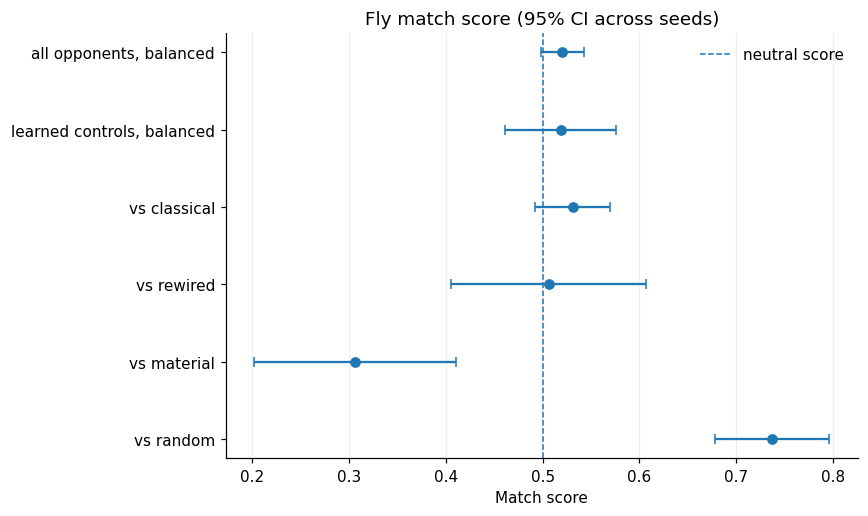

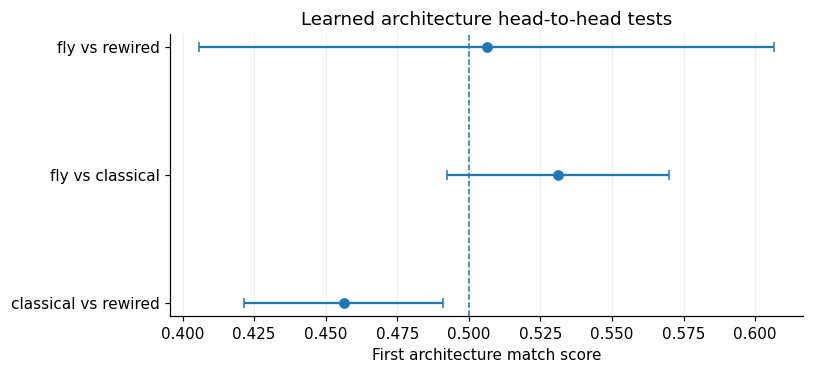

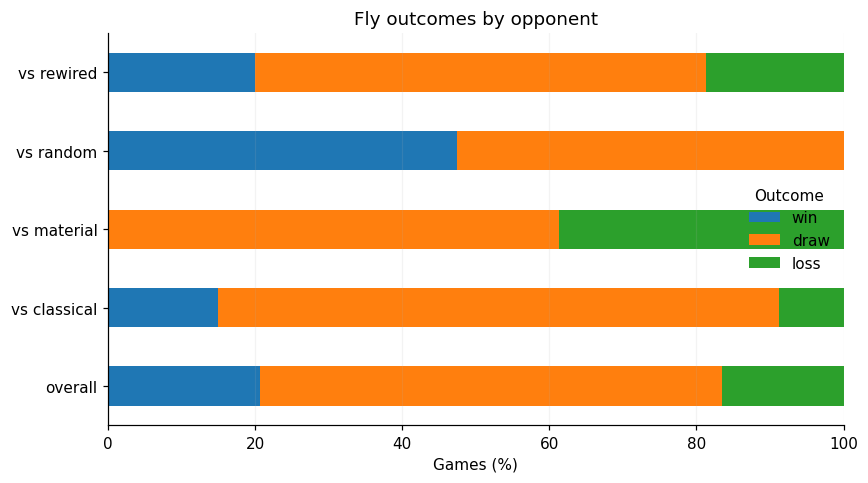

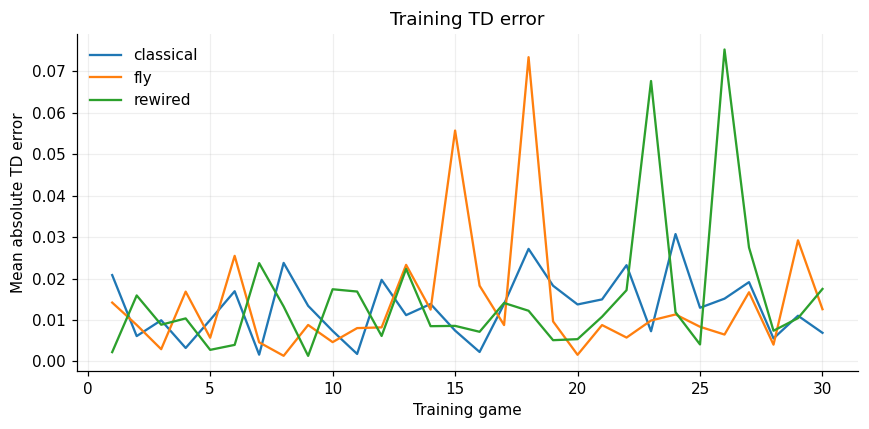

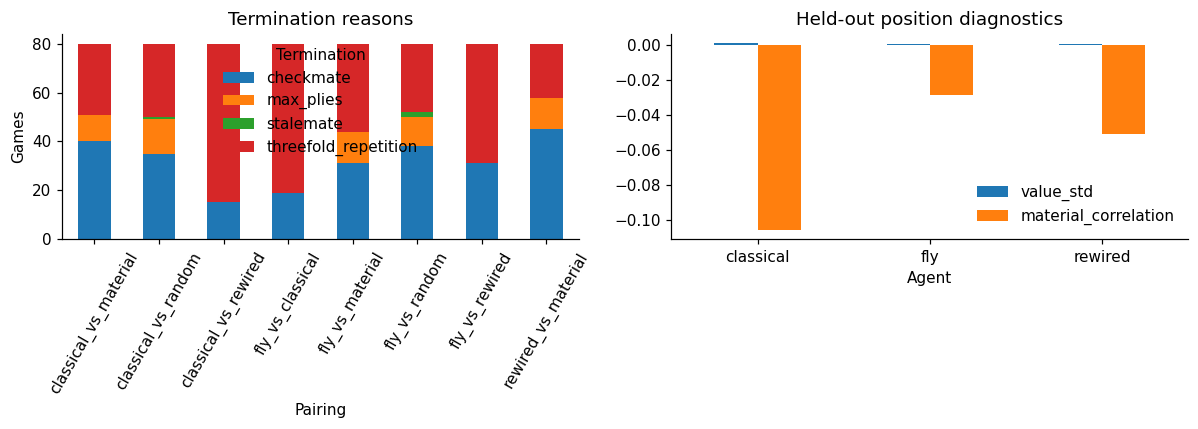

In [14]:
plot_scopes = [
    "all opponents, balanced",
    "learned controls, balanced",
    "vs classical",
    "vs rewired",
    "vs material",
    "vs random",
]
plot_rows = fly_robust_tests.set_index("scope").loc[plot_scopes].reset_index().iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 4.8))
y = np.arange(len(plot_rows))
left = plot_rows["mean_score"] - plot_rows["t_ci95_low"]
right = plot_rows["t_ci95_high"] - plot_rows["mean_score"]
ax.errorbar(
    plot_rows["mean_score"],
    y,
    xerr=np.vstack([left, right]),
    fmt="o",
    capsize=3,
)
ax.axvline(0.5, linestyle="--", linewidth=1, label="neutral score")
ax.set_yticks(y, plot_rows["scope"])
ax.set_xlabel("Match score")
ax.set_title("Fly match score (95% CI across seeds)")
ax.grid(axis="x", alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

pair_plot = architecture_pairwise_tests.copy().iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 3.5))
y = np.arange(len(pair_plot))
left = pair_plot["mean_score"] - pair_plot["t_ci95_low"]
right = pair_plot["t_ci95_high"] - pair_plot["mean_score"]
ax.errorbar(pair_plot["mean_score"], y, xerr=np.vstack([left, right]), fmt="o", capsize=3)
ax.axvline(0.5, linestyle="--", linewidth=1)
ax.set_yticks(y, pair_plot["scope"])
ax.set_xlabel("First architecture match score")
ax.set_title("Learned architecture head-to-head tests")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

outcome_plot = fly_outcomes.set_index("group")[["win_pct", "draw_pct", "loss_pct"]]
ax = outcome_plot.plot.barh(stacked=True, figsize=(8, 4.5))
ax.set_xlim(0, 100)
ax.set_xlabel("Games (%)")
ax.set_ylabel("")
ax.set_title("Fly outcomes by opponent")
ax.legend(title="Outcome", labels=["win", "draw", "loss"], frameon=False)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

if len(fly_vs_rewired_by_suite) > 1:
    fig, ax = plt.subplots(figsize=(7, 3.6))
    suite_plot = fly_vs_rewired_by_suite.sort_values("suite")
    lower = suite_plot["mean_score"] - suite_plot["ci95_low"]
    upper = suite_plot["ci95_high"] - suite_plot["mean_score"]
    ax.errorbar(
        suite_plot["suite"],
        suite_plot["mean_score"],
        yerr=np.vstack([lower, upper]),
        fmt="o-",
        capsize=3,
    )
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_xticks(suite_plot["suite"])
    ax.set_xlabel("Evaluation suite")
    ax.set_ylabel("Fly match score vs rewired")
    ax.set_title("Replication across evaluation suites")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
training_mean = training_history.groupby(["agent", "game"], as_index=False)["mean_abs_td_error"].mean()
for agent_name, group in training_mean.groupby("agent"):
    ax.plot(group["game"], group["mean_abs_td_error"], label=agent_name)
ax.set_xlabel("Training game")
ax.set_ylabel("Mean absolute TD error")
ax.set_title("Training TD error")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
termination_pivot = termination_results.pivot(index="pairing", columns="termination", values="games").fillna(0)
termination_pivot.plot.bar(stacked=True, ax=axes[0])
axes[0].set_xlabel("Pairing")
axes[0].set_ylabel("Games")
axes[0].set_title("Termination reasons")
axes[0].tick_params(axis="x", rotation=60)
axes[0].legend(title="Termination", frameon=False)

diagnostic_plot = position_diagnostics.groupby("agent").agg(
    value_std=("value_std", "mean"),
    material_correlation=("material_correlation", "mean"),
)
diagnostic_plot.plot.bar(ax=axes[1])
axes[1].set_xlabel("Agent")
axes[1].set_title("Held-out position diagnostics")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()


## Example games


Saved game_01_seed_11_fly_vs_classical.gif


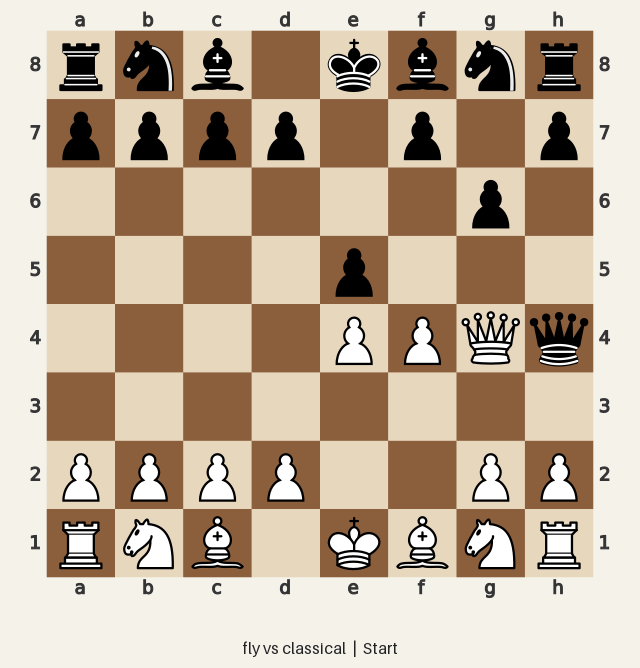

Saved game_02_seed_11_fly_vs_classical.gif


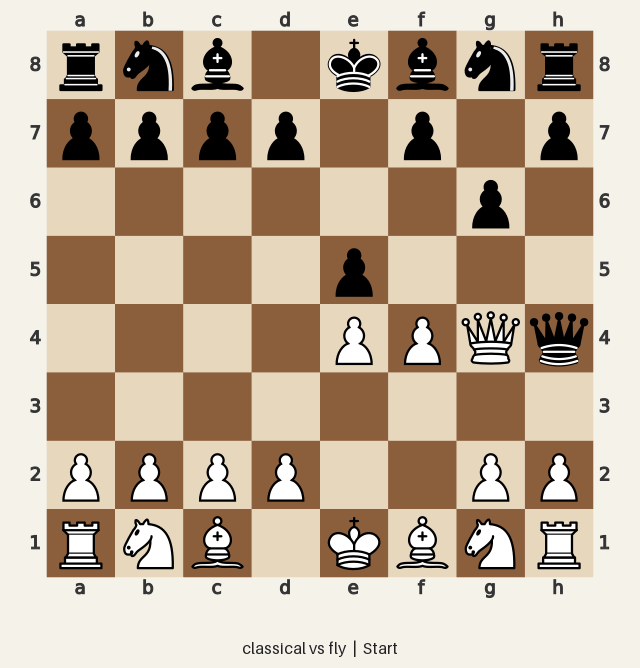

Saved game_03_seed_11_fly_vs_classical.gif


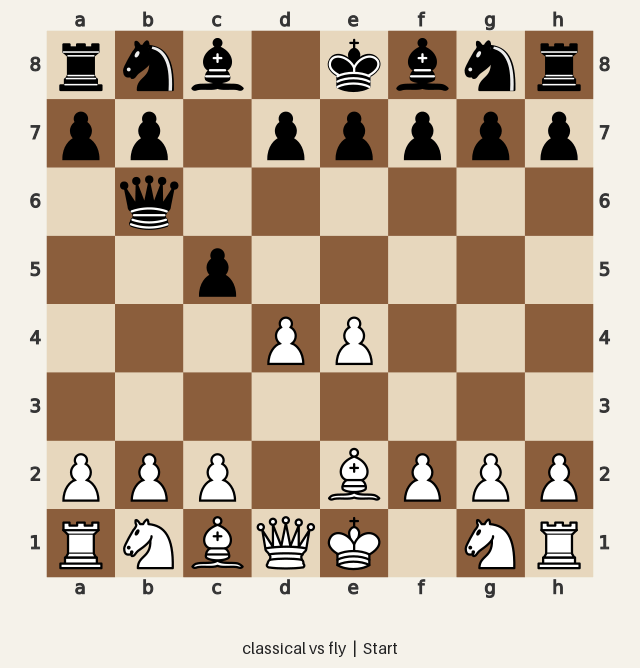

Saved game_04_seed_11_fly_vs_rewired.gif


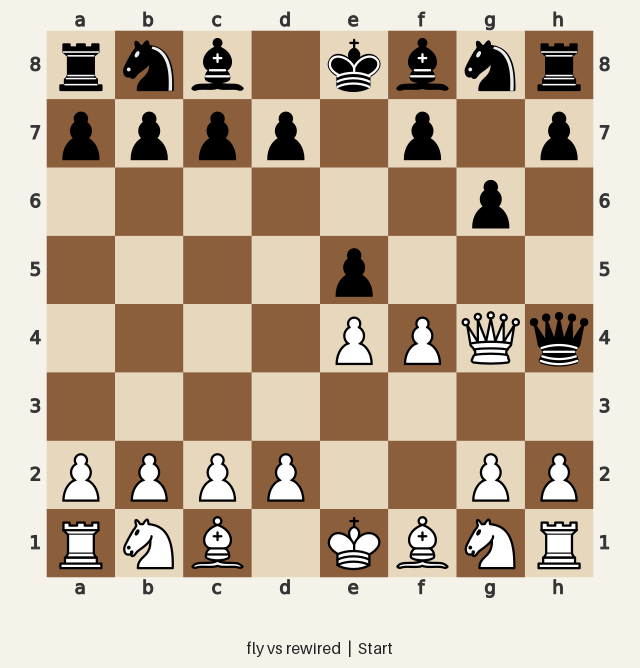

In [15]:
def render_position(fen, title, image_size=640):
    board = chess.Board(fen)
    board_size = image_size - 48
    board_svg = chess.svg.board(
        board=board,
        size=board_size,
        coordinates=True,
        colors={
            "square light": "#e7d7bd",
            "square dark": "#8b5e3c",
            "margin": "#f5f2ea",
            "coord": "#333333",
        },
    )
    board_png = cairosvg.svg2png(
        bytestring=board_svg.encode("utf-8"),
        output_width=board_size,
        output_height=board_size,
    )
    board_image = PILImage.open(BytesIO(board_png)).convert("RGB")
    image = PILImage.new("RGB", (image_size, image_size + 28), "#f5f2ea")
    image.paste(board_image, (24, 8))
    draw = ImageDraw.Draw(image)
    try:
        title_font = ImageFont.load_default(size=16)
    except TypeError:
        title_font = ImageFont.load_default()
    draw.text((image_size / 2, image_size + 8), title, font=title_font, fill="#222222", anchor="mm")
    return image


def save_game_gif(game, path, duration_ms=650):
    frames = [
        render_position(
            fen,
            f"{game['white']} vs {game['black']}  |  {label}",
        )
        for fen, label in zip(game["positions"], game["labels"])
    ]
    frames[0].save(
        path,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0,
        optimize=False,
    )
    return path


selected_gifs = []
seen_cases = set()
for game in gif_candidates:
    fly_outcome = (
        "win" if game["winner"] == "fly" else "draw" if game["winner"] == "draw" else "loss"
    )
    case = (game["pairing"], fly_outcome)
    if case in seen_cases:
        continue
    seen_cases.add(case)
    selected_gifs.append(game)
    if len(selected_gifs) >= GIF_GAMES:
        break

gif_paths = []
for index, game in enumerate(selected_gifs, start=1):
    filename = f"game_{index:02d}_seed_{game['seed']}_{game['pairing']}.gif"
    path = RESULTS_DIR / filename
    save_game_gif(game, path)
    gif_paths.append(path)
    print(f"Saved {path.name}")
    display(NotebookImage(filename=str(path)))


## Export


In [16]:
config = {
    "run_mode": RUN_MODE,
    "experiment_seeds": EXPERIMENT_SEEDS,
    "self_play_games": SELF_PLAY_GAMES,
    "maximum_plies": MAX_PLIES,
    "evaluation_suites": EVALUATION_SUITES,
    "positions_per_suite": POSITIONS_PER_SUITE,
    "evaluation_repeats_per_color": EVALUATION_REPEATS,
    "evaluation_positions_total": EVALUATION_POSITIONS,
    "games_per_pairing_per_seed": GAMES_PER_PAIRING_PER_SEED,
    "held_out_positions": HELD_OUT_POSITIONS,
    "pairings": PAIRINGS,
    "learning_rate": LEARNING_RATE,
    "discount": DISCOUNT,
    "epsilon_start": EPSILON_START,
    "epsilon_end": EPSILON_END,
    "material_shaping": MATERIAL_SHAPING,
    "draw_contempt": DRAW_CONTEMPT,
    "propagation_steps": PROPAGATION_STEPS,
    "reservoir_neurons": RESERVOIR_NEURONS,
    "readout_neurons": READOUT_NEURONS,
    "bootstrap_reps": BOOTSTRAP_REPS,
    "sign_flip_reps": SIGN_FLIP_REPS,
    "analysis_seed": ANALYSIS_SEED,
}
with open(RESULTS_DIR / "experiment_config.json", "w", encoding="utf-8") as handle:
    json.dump(config, handle, indent=2)

archive_path = shutil.make_archive(
    str(RESULTS_DIR.parent / "connectome_multiseed_results"),
    "zip",
    root_dir=RESULTS_DIR,
)
print(f"Saved results archive: {archive_path}")
if IN_COLAB:
    print("To download it now, run:")
    print("from google.colab import files; files.download('" + archive_path + "')")


Saved results archive: /content/connectome_multiseed_results.zip
To download it now, run:
from google.colab import files; files.download('/content/connectome_multiseed_results.zip')


## Statistical notes

The main replication unit is the independently trained seed. The standard profile uses 8 seeds and the robust profile uses 16. Evaluation precision is increased separately through disjoint position suites, both colors, and repeated tie-breaking trials.

The notebook reports t-based and seed-bootstrap confidence intervals, sign-flip tests, Wilcoxon signed-rank tests, a seed-direction sign test, leave-one-seed-out stability, Holm correction for multiple architecture comparisons, a two-way seed/position bootstrap for Fly vs rewired, evaluation-suite replication, color sensitivity, and a maximum-ply sensitivity check. Repeated games from one trained seed are never treated as independent training replicates.
